In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

import warnings
warnings.filterwarnings('ignore')


In [2]:
orders = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/orders.csv")
order_products = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv")
products = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/products.csv")


In [3]:
print(orders.shape)
print(order_products.shape)
print(products.shape)

orders.head()


(3421083, 7)
(32434489, 4)
(49688, 4)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


### Data Cleaning

In [4]:
orders.isnull().sum()
order_products.isnull().sum()
products.isnull().sum()


product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [5]:
orders.duplicated().sum()
order_products.duplicated().sum()
products.duplicated().sum()


np.int64(0)

### Merge Datasets

In [6]:
df = order_products.merge(
    orders[['order_id', 'user_id']],
    on='order_id'
)

df = df.merge(
    products[['product_id', 'product_name']],
    on='product_id'
)

df.head()


,order_id,product_id,add_to_cart_order,reordered,user_id,product_name
0,2,33120,1,1,202279,Organic Egg Whites
1,2,28985,2,1,202279,Michigan Organic Kale
2,2,9327,3,0,202279,Garlic Powder
3,2,45918,4,1,202279,Coconut Butter
4,2,30035,5,0,202279,Natural Sweetener


In [7]:
data = order_products.merge(orders, on="order_id")
data = data.merge(products, on="product_id")

data.head()


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13


## EDA

### Number of users

In [8]:
data['user_id'].nunique()


206209

### Number of products

In [9]:
data['product_id'].nunique()


49677

### Most purchased products

product_name
Banana                    472565
Bag of Organic Bananas    379450
Organic Strawberries      264683
Organic Baby Spinach      241921
Organic Hass Avocado      213584
Organic Avocado           176815
Large Lemon               152657
Strawberries              142951
Limes                     140627
Organic Whole Milk        137905
Name: count, dtype: int64


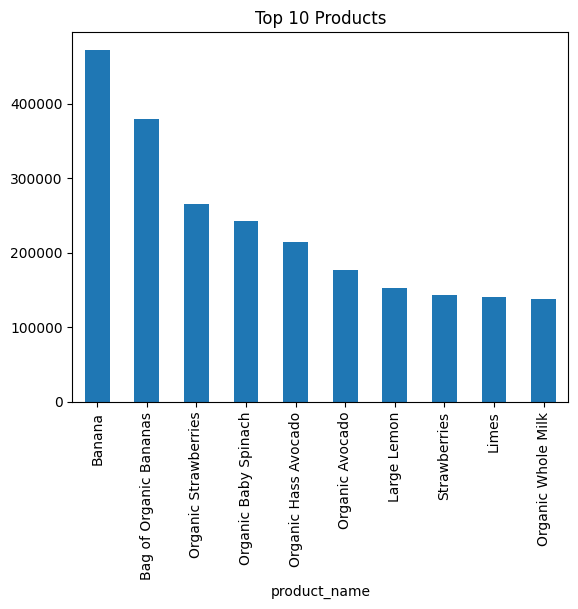

In [10]:
top_products = data['product_name'].value_counts().head(10)
print(top_products)


top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()


In [11]:
orders_per_user = data.groupby('user_id')['order_id'].count()

orders_per_user.describe()


count    206209.000000
mean        157.289396
std         204.208233
min           3.000000
25%          39.000000
50%          83.000000
75%         188.000000
max        3725.000000
Name: order_id, dtype: float64

### Reduce data size

In [12]:
data = data.sample(50000, random_state=42)


In [13]:
data['user_id']

29481110    135284
2852353       7293
11194500    111385
15909397    147365
6101870      99290
             ...  
21676098      5178
26687880    174821
26549191    161762
14193745     24950
13714122    116122
Name: user_id, Length: 50000, dtype: int64

## Feature Engineering

In [14]:
user_item_matrix = data.pivot_table(
    index='user_id',
    columns='product_id',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

user_item_matrix[user_item_matrix > 0] = 1

user_item_matrix.shape




(38240, 11644)

In [15]:
from sklearn.model_selection import train_test_split

train_users, test_users = train_test_split(
    user_item_matrix.index,
    test_size=0.2,
    random_state=42
)

train_matrix = user_item_matrix.loc[train_users]
test_matrix = user_item_matrix.loc[test_users]


In [16]:
from scipy.sparse.linalg import svds
import numpy as np

matrix = train_matrix.values

U, sigma, Vt = svds(matrix, k=50)

sigma = np.diag(sigma)

predicted = np.dot(np.dot(U, sigma), Vt)

pred_df = pd.DataFrame(
    predicted,
    index=train_matrix.index,
    columns=train_matrix.columns
)


In [17]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(
    train_matrix.values.flatten(),
    predicted.flatten()
))

print("RMSE:", rmse)


accuracy = (1 - rmse) * 100

print(f"Accuracy: {accuracy:.2f}%")


RMSE: 0.009644173399127083
Accuracy: 99.04%


In [18]:
def recommend_products(user_id, n=5):

    scores = pred_df.loc[user_id]

    recommended = scores.sort_values(ascending=False).head(n)

    return recommended.index.tolist()


In [19]:
pred_df.index[:10]

Index([150051, 169653, 193556, 66661, 49536, 96188, 174810, 195502, 34192,
       199683],
      dtype='int64', name='user_id')

In [20]:

recommended_ids = recommend_products(user_id=193556, n=5)

recommended_products = products[products['product_id'].isin(recommended_ids)]

print(recommended_products[['product_id', 'product_name']])

       product_id              product_name
8276         8277  Apple Honeycrisp Organic
8517         8518         Organic Red Onion
16796       16797              Strawberries
17793       17794                   Carrots
32999       33000         Pure Irish Butter
